Double pass doesn't make sense for FC, so we consider single pass and include unpoled and poled shit.

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.fcon import FPulsed_lin
from NeedALight.utils import blocks
from custom_poling.core.target import Target
from custom_poling.core.custom_crystal import CustomCrystal
from tqdm import tqdm

Describe the process, p+s->i. Discribe what JSD and the decomp are basically include a big portion of note here.

In [23]:
#Parameters for calculations

N = 301  # Number of frequency values
Np = 0.01717 # Number of pump photons: Vary this to modify gain values 
vp = 0.1  # pump velocity
l = 1.0  # amplification region length
sig = 1  # pump wave packet spread
a = 1.61 / 1.13  # from symmetric grp. vel. matching

#Ensuring that we are in the symmetric grp. vel. matching regime.
def symmetric_v(vp, sig, l, a):
    vi = vp / (1 - 2 * a * vp / (l * sig))
    vs = vp / (1 + 2 * a * vp / (l * sig))
    return vs, vi

vs, vi = symmetric_v(vp, sig, l, a)



#Frequency values
wi = -15
wf = 15
dw = (wf - wi) / (N - 1)
w = np.linspace(wi, wf, N)

#Defining gaussian pump pulse
def pump(x, Np, scale=1):
    return np.sqrt(Np)*np.exp(-((x) ** 2) / (2 * (sig*scale) ** 2)) / np.power(np.pi * (sig*scale)**2, 1 / 4)

# Crystal properties
Ndomain = 1000
dz = l / Ndomain
domain_width = dz
number_domains = Ndomain
L = number_domains * domain_width
k0 = np.pi / domain_width

# Numerical integration parameters for generating domain
k_range = 100/L
dk = k_range/401
k_array = np.arange(k0-k_range/2,k0+k_range/2,dk)

Poling

In [24]:
# Create a custom crystal object
custom_crystal_gauss = CustomCrystal(domain_width,number_domains)
domain_middles_gauss = custom_crystal_gauss.domain_middles

#Define and plot the target function
std = 10
height = 0.025
target_pmf_gauss = lambda k:1j*height*np.exp(-(k-k0)**2/(2*std**2))*np.exp(1j * L/2 * k)
target_gauss = Target(target_pmf_gauss,k_array)

# Compute and plot the target amplitude
target_amplitude_gauss = target_gauss.compute_amplitude(k0,domain_middles_gauss)

# Compute and plot the custom domains
custom_domains_gauss = custom_crystal_gauss.compute_domains(target_amplitude_gauss,k0)

#Shifting the domain such that we are at 0 central frequency
if len(custom_domains_gauss)==Ndomain:
    domain = custom_domains_gauss * np.asarray([1, -1] * int(Ndomain / 2)) 
else:
    domain = custom_domains_gauss * np.asarray([1, -1] * int(Ndomain / 2)+[1]) 

domain_sinc = [1]
domain_gauss = domain

#Proper scale factor so that Gaussian PMF and Gaussian Pump have the same width
sc=std/(2*a)

Comparing unpoled and gaussian poled SPDC, we required a higher value of Np to operate at the same average number of signal photons. Similarly, we need to a higher value of Np here to operate at the "same level of gain".. maybe ask Nico about this.

In [25]:
#Initializing pump
Np_g = 2.2  #For gaussian poling, need higher interaction strength
pump_Np_s = lambda x: pump(x, Np)
pump_Np_g = lambda x: pump(x, Np_g*np.sqrt(sc), scale=sc) #Scale is modified with poling, defined in the previous cell

#Generating JSD etc
T_s, J_s, Eff_s, S_s, Us_s, Ui_s, Vs_s, Vi_s = FPulsed_lin(vs, vi, vp, pump_Np_s, domain_sinc, l, l, w)
T_g, J_g, Eff_g, S_g, Us_g, Ui_g, Vs_g, Vi_g = FPulsed_lin(vs, vi, vp, pump_Np_g, domain_gauss, dz, l, w)

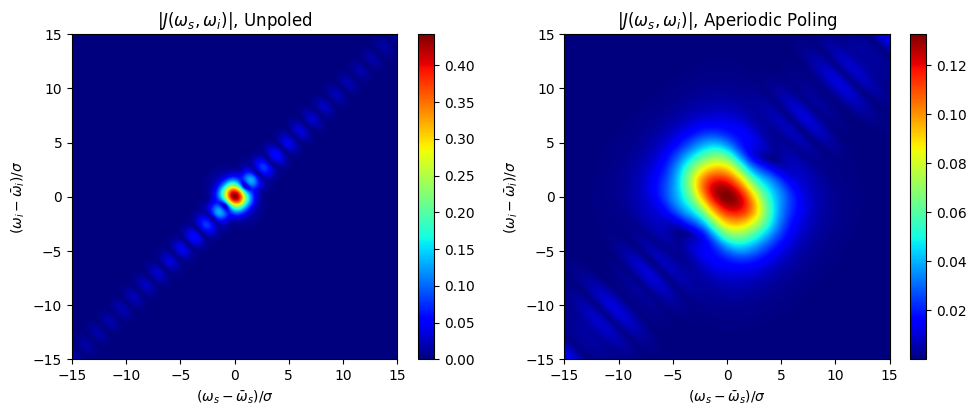

The unpoled Selectivity is S=0.523
The aperiodically poled Selectivity is S=0.766


In [27]:
#Generating plot of JSD
fig, ax = plt.subplots(1, 2, figsize=(10,4))

im = ax[0].imshow(np.abs(J_s), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
ax[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[0].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
ax[0].set_title(r"$|J(\omega_{s}, \omega_{i})| $, Unpoled")
plt.colorbar(im, orientation="vertical")

im1 = ax[1].imshow(np.abs(J_g), cmap="jet", origin="lower",extent=[w[0],w[N-1],w[0],w[N-1]])
ax[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[1].set_ylabel(r"$(\omega_{i}-\bar{\omega}_{i})/\sigma$")
ax[1].set_title(r"$|J(\omega_{s}, \omega_{i})| $, Aperiodic Poling")
plt.colorbar(im1, orientation="vertical")

fig.tight_layout()
plt.show()


print('The unpoled Selectivity is S=%1.3f' %S_s)
print('The aperiodically poled Selectivity is S=%1.3f' %S_g)

Next we show the signal and ilder input/output temporal modes for an **unpoled** nonlinear region. We print the conversion efficiency.

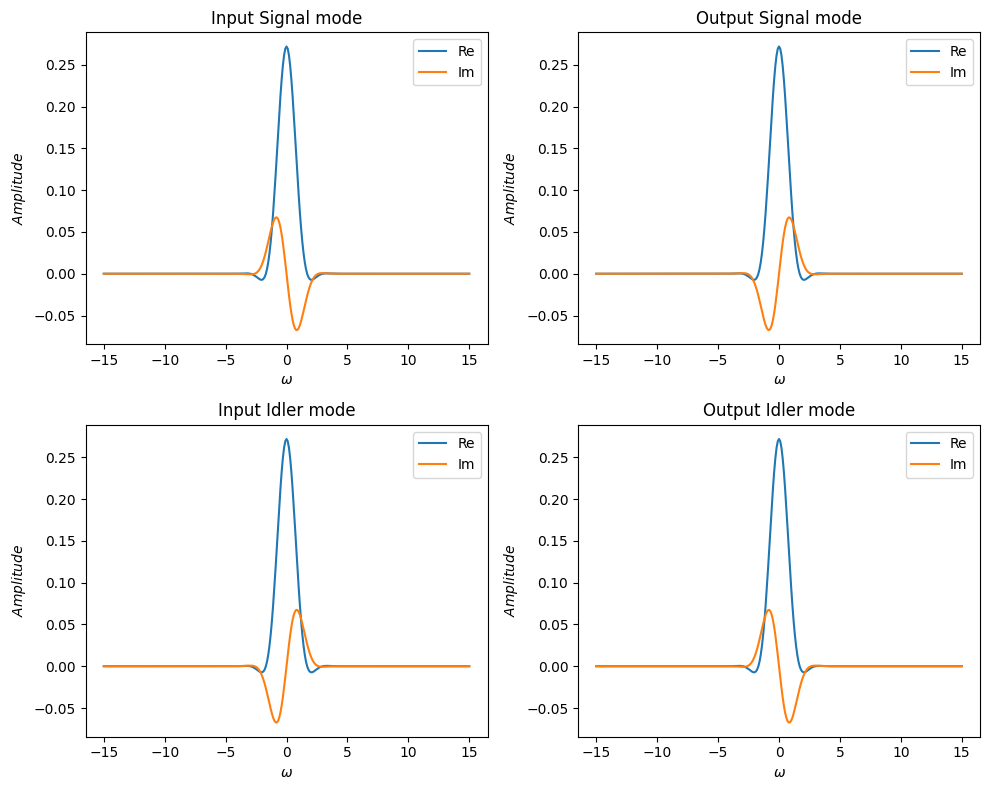

The conversion efficiency is η = 0.904


In [28]:
#Looking at the temporal modes
mark=1 #this just takes the first mode of interest. Choose a different value to look at different ones.

fig, ax1 = plt.subplots(2,2, figsize = (10,8))


ax1[0,0].plot(w, np.real(np.exp(-1j*np.angle(Vs_s[(N-1)//2,-mark]))*Vs_s[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[0,0].plot(w, np.imag(np.exp(-1j*np.angle(Vs_s[(N-1)//2,-mark]))*Vs_s[:,-mark]), label='Im')
ax1[0,0].set_xlabel(r"$\omega$")
ax1[0,0].set_ylabel(r"$Amplitude$")
ax1[0,0].set_title('Input Signal mode')
ax1[0,0].legend()

ax1[0,1].plot(w, np.real(np.exp(-1j*np.angle(Us_s[(N-1)//2,-mark]))*Us_s[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[0,1].plot(w, np.imag(np.exp(-1j*np.angle(Us_s[(N-1)//2,-mark]))*Us_s[:,-mark]), label='Im')
ax1[0,1].set_xlabel(r"$\omega$")
ax1[0,1].set_ylabel(r"$Amplitude$")
ax1[0,1].set_title('Output Signal mode')
ax1[0,1].legend()

ax1[1,0].plot(w, np.real(np.exp(-1j*np.angle(Vi_s[(N-1)//2,-mark]))*Vi_s[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[1,0].plot(w, np.imag(np.exp(-1j*np.angle(Vi_s[(N-1)//2,-mark]))*Vi_s[:,-mark]), label='Im')
ax1[1,0].set_xlabel(r"$\omega$")
ax1[1,0].set_ylabel(r"$Amplitude$")
ax1[1,0].set_title('Input Idler mode')
ax1[1,0].legend()

ax1[1,1].plot(w, np.real(np.exp(-1j*np.angle(Ui_s[(N-1)//2,-mark]))*Ui_s[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[1,1].plot(w, np.imag(np.exp(-1j*np.angle(Ui_s[(N-1)//2,-mark]))*Ui_s[:,-mark]), label='Im')
ax1[1,1].set_xlabel(r"$\omega$")
ax1[1,1].set_ylabel(r"$Amplitude$")
ax1[1,1].set_title('Output Idler mode')
ax1[1,1].legend()


fig.tight_layout()
plt.show()

print("The conversion efficiency is \u03B7 = %1.3f" %Eff_s[-mark])

Next we show the signal and ilder input/output temporal modes for an **aperiodically poled** nonlinear region. We print the conversion efficiency.

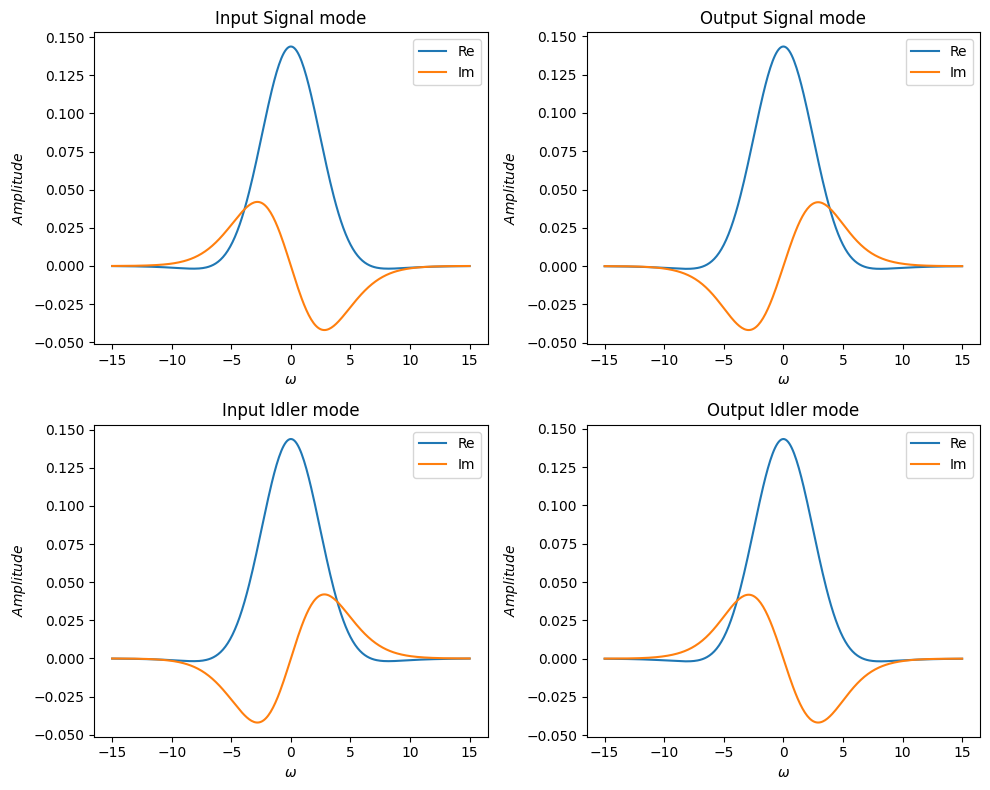

The conversion efficiency is η = 0.937


In [29]:
#Looking at the temporal modes
mark=1 #this just takes the first mode of interest. Choose a different value to look at different ones.

fig, ax1 = plt.subplots(2,2, figsize = (10,8))


ax1[0,0].plot(w, np.real(np.exp(-1j*np.angle(Vs_g[(N-1)//2,-mark]))*Vs_g[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[0,0].plot(w, np.imag(np.exp(-1j*np.angle(Vs_g[(N-1)//2,-mark]))*Vs_g[:,-mark]), label='Im')
ax1[0,0].set_xlabel(r"$\omega$")
ax1[0,0].set_ylabel(r"$Amplitude$")
ax1[0,0].set_title('Input Signal mode')
ax1[0,0].legend()

ax1[0,1].plot(w, np.real(np.exp(-1j*np.angle(Us_g[(N-1)//2,-mark]))*Us_g[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[0,1].plot(w, np.imag(np.exp(-1j*np.angle(Us_g[(N-1)//2,-mark]))*Us_g[:,-mark]), label='Im')
ax1[0,1].set_xlabel(r"$\omega$")
ax1[0,1].set_ylabel(r"$Amplitude$")
ax1[0,1].set_title('Output Signal mode')
ax1[0,1].legend()

ax1[1,0].plot(w, np.real(np.exp(-1j*np.angle(Vi_g[(N-1)//2,-mark]))*Vi_g[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[1,0].plot(w, np.imag(np.exp(-1j*np.angle(Vi_g[(N-1)//2,-mark]))*Vi_g[:,-mark]), label='Im')
ax1[1,0].set_xlabel(r"$\omega$")
ax1[1,0].set_ylabel(r"$Amplitude$")
ax1[1,0].set_title('Input Idler mode')
ax1[1,0].legend()

ax1[1,1].plot(w, np.real(np.exp(-1j*np.angle(Ui_g[(N-1)//2,-mark]))*Ui_g[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax1[1,1].plot(w, np.imag(np.exp(-1j*np.angle(Ui_g[(N-1)//2,-mark]))*Ui_g[:,-mark]), label='Im')
ax1[1,1].set_xlabel(r"$\omega$")
ax1[1,1].set_ylabel(r"$Amplitude$")
ax1[1,1].set_title('Output Idler mode')
ax1[1,1].legend()


fig.tight_layout()
plt.show()

print("The conversion efficiency is \u03B7 = %1.3f" %Eff_g[-mark])

In [30]:
np.sum(Eff_s), np.sum(Eff_g)

(np.float64(1.283638085425618), np.float64(1.080393201971918))

Mention that we choose the same range of Np as the SPDC examples. Not sure how to characterize the level of "gain". Describe what the T and R things are. The range of Np is chosen such that if this was SPDC the number of average signal photons would vary from 0 to 20

In [44]:
#Efficiency and Selectivity as a function of Np
nstep = 30 ##number of steps for photon number (Np) range
#Unpoled parameters
npi_s = 0.000002  #initial pump photon number (Np)
npf_s = 0.02174032    #final pump photon number (Np)    #number of steps for photon number (Np) range
num_pump_s = np.linspace(npi_s,npf_s,nstep) 

#Poled parameters
npi_g = 0.00024 #initial pump photon number (Np)
npf_g = 2.46045  #final pump photon number (Np)
num_pump_g = np.linspace(npi_g,npf_g,nstep)

#Initializing
t_s = np.zeros_like(num_pump_s)
r_s = np.zeros_like(num_pump_s)
S_s = np.zeros_like(num_pump_s)
Eff_s =  np.zeros_like(num_pump_s)

t_g = np.zeros_like(num_pump_s)
r_g = np.zeros_like(num_pump_s)
S_g = np.zeros_like(num_pump_s)
Eff_g =  np.zeros_like(num_pump_s)


#Generating low gain input modes
_T_s, _J_s, _Eff_s, _S_s, _Us_s, _Ui_s, Vs_sl, _Vi_s = FPulsed_lin(vs, vi, vp, pump_Np_s, domain_sinc, l, l, w)
_T_g, _J_g, _Eff_g, _S_g, _Us_g, _Ui_g, Vs_gl, _Vi_g = FPulsed_lin(vs, vi, vp, pump_Np_g, domain_gauss, dz, l, w)
Low_s = np.conj(Vs_sl[:,-1])
Low_g = np.conj(Vs_gl[:,-1])

T_s = np.zeros([len(Low_s), len(num_pump_s)],dtype= np.complex128)
R_s = np.zeros([len(Low_s), len(num_pump_s)],dtype= np.complex128)
T_g = np.zeros([len(Low_g), len(num_pump_g)],dtype= np.complex128)
R_g = np.zeros([len(Low_g), len(num_pump_g)],dtype= np.complex128)


for i in tqdm(range(nstep)):
    pump_Np_s = lambda x: pump(x, num_pump_s[i])
    pump_Np_g = lambda x: pump(x, num_pump_g[i]*np.sqrt(sc), scale=sc)

    T_sT, _J_s, Eff_sT, S_sT, _Us_s, _Ui_s, _Vs_sl, _Vi_s = FPulsed_lin(vs, vi, vp, pump_Np_s, domain_sinc, l, l, w)
    T_gT, _J_g, Eff_gT, S_gT, _Us_g, _Ui_g, _Vs_gl, _Vi_g = FPulsed_lin(vs, vi, vp, pump_Np_g, domain_gauss, dz, l, w)

    #Unpoled quantities
    Eff_s[i] = Eff_sT[-1]
    S_s[i] = S_sT 
    
    Tinv = np.linalg.inv(T_sT)
    T_ss, T_si, T_is, T_ii = blocks(Tinv.conj())

    T_s[:,i] = T_ss.conj()@Low_s
    R_s[:,i] = T_is.conj()@Low_s

    t_s[i] = np.vdot(T_s[:,i],T_s[:,i]).real
    r_s[i] = np.vdot(R_s[:,i],R_s[:,i]).real

    #Aperiodically poled quantities
    Eff_g[i] = Eff_gT[-1]
    S_g[i] = S_gT 
    
    Tinv_g = np.linalg.inv(T_gT)
    T_ss_g, T_si_g, T_is_g, T_ii_g = blocks(Tinv_g.conj())

    T_g[:,i] = T_ss_g.conj()@Low_g
    R_g[:,i] = T_is_g.conj()@Low_g

    t_g[i] = np.vdot(T_g[:,i],T_g[:,i]).real
    r_g[i] = np.vdot(R_g[:,i],R_g[:,i]).real

100%|██████████| 30/30 [03:31<00:00,  7.06s/it]


Transmission and Reflection coefficients.

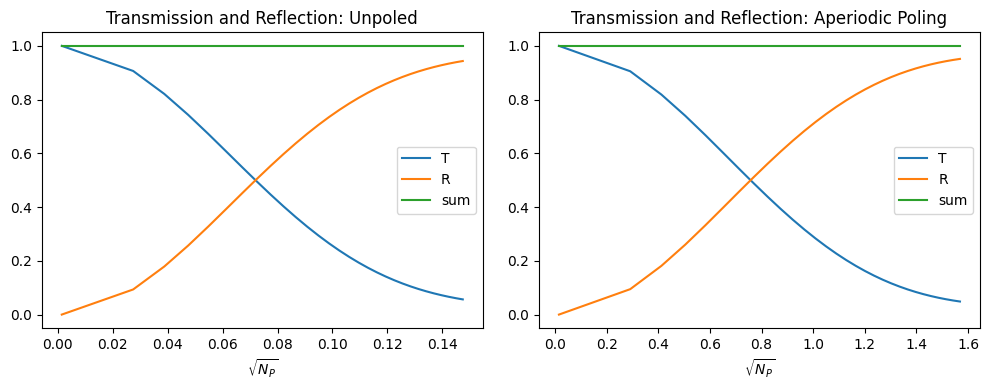

In [45]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].plot(np.sqrt(num_pump_s),t_s, label='T')
ax[0].plot(np.sqrt(num_pump_s),r_s,label='R')
ax[0].plot(np.sqrt(num_pump_s),r_s+t_s,label='sum')
ax[0].set_xlabel(r'$\sqrt{N_P}$')
ax[0].set_title('Transmission and Reflection: Unpoled')
ax[0].legend()
 
ax[1].plot(np.sqrt(num_pump_g),t_g, label='T')
ax[1].plot(np.sqrt(num_pump_g),r_g,label='R')
ax[1].plot(np.sqrt(num_pump_g),r_g+t_g,label='sum')
ax[1].set_xlabel(r'$\sqrt{N_P}$')
ax[1].set_title('Transmission and Reflection: Aperiodic Poling')
ax[1].legend()


fig.tight_layout()
plt.show()

Efficiency as a function of pump strength.

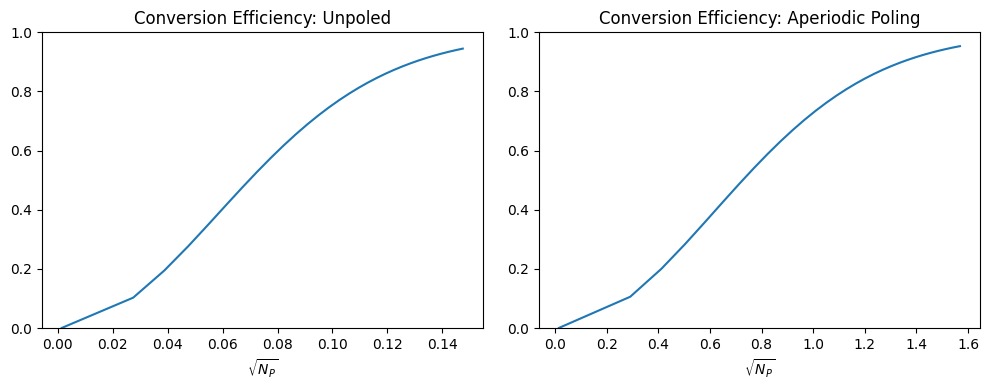

In [49]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].plot(np.sqrt(num_pump_s),Eff_s)
ax[0].set_xlabel(r'$\sqrt{N_P}$')
ax[0].set_ylim([0, 1])
ax[0].set_title('Conversion Efficiency: Unpoled')
 
ax[1].plot(np.sqrt(num_pump_g),Eff_g)
ax[1].set_xlabel(r'$\sqrt{N_P}$')
ax[1].set_ylim([0, 1])
ax[1].set_title('Conversion Efficiency: Aperiodic Poling')


fig.tight_layout()
plt.show()

Selectivity as a function of pump strength.

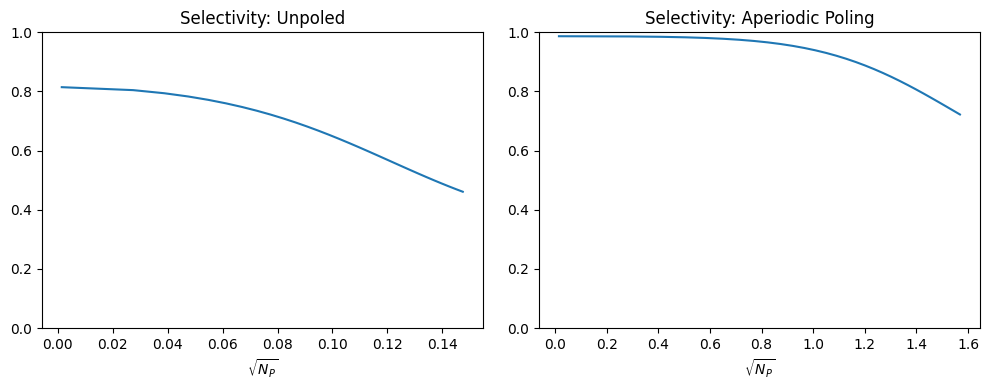

In [50]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].plot(np.sqrt(num_pump_s),S_s)
ax[0].set_xlabel(r'$\sqrt{N_P}$')
ax[0].set_ylim([0, 1])
ax[0].set_title('Selectivity: Unpoled')
 
ax[1].plot(np.sqrt(num_pump_g),S_g)
ax[1].set_xlabel(r'$\sqrt{N_P}$')
ax[1].set_ylim([0, 1])
ax[1].set_title('Selectivity: Aperiodic Poling')


fig.tight_layout()
plt.show()

From the figures, we can gather that although aperiodic poling has a higher selectivity (initially single-mode), the conversion efficiency and transmission/relfection coefficients are very similar to the unpoled case.